In [5]:
import math
w01=5
w11=2
w21=2

w02=3
w12=20
w22=20

def distance(w0,w1,w2,x1,x2):
    numerator = abs(w0+w1*x1+w2*x2)
    denominator=math.sqrt(w1**2+w2**2)
    return numerator/denominator

x1=1
x2=2
d1=distance(w01,w11,w21,x1,x2)
d2=distance(w02,w12,w22,x1,x2)
print("Distance from classifier 1:",d1)
print("Distance from classifier 2:",d2)
if d1>d2:
    print("Classifier 1 is better")
else:
    print("Classifier 2 is better")

Distance from classifier 1: 3.8890872965260113
Distance from classifier 2: 2.2273863607376247
Classifier 1 is better


w1 = 0.8000000000000002
w2 = 0.4
b  = -1.8000000000000003

Optimal Hyperplane:
0.80x1 + 0.40x2 + (-1.80) = 0

Support Vectors:
[[1. 0.]
 [3. 1.]]


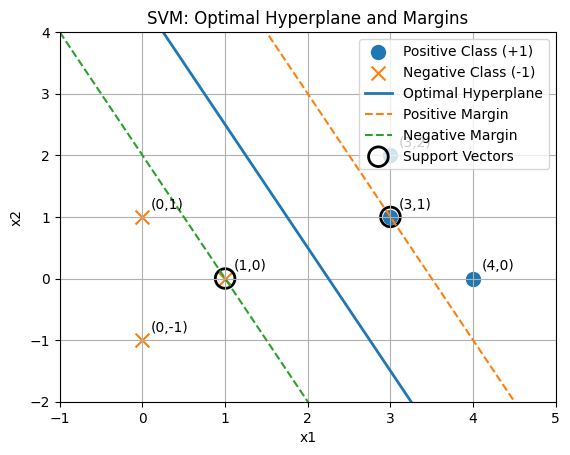

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# -----------------------------
# 1. Training data
# -----------------------------

# Positive class (+1)
positive = np.array([
    [3, 1],
    [3, 2],
    [4, 0]
])

# Negative class (-1)
negative = np.array([
    [1, 0],
    [0, 1],
    [0, -1]
])

# Combine the data
X = np.vstack((positive, negative))

# Class labels
y = np.array([1, 1, 1, -1, -1, -1])


# -----------------------------
# 2. Create SVM classifier
# -----------------------------

# Linear SVM
model = SVC(kernel='linear', C=1000000)

# Train the model
model.fit(X, y)


# -----------------------------
# 3. Get hyperplane parameters
# -----------------------------

w = model.coef_[0]
b = model.intercept_[0]

print("w1 =", w[0])
print("w2 =", w[1])
print("b  =", b)

print("\nOptimal Hyperplane:")
print(f"{w[0]:.2f}x1 + {w[1]:.2f}x2 + ({b:.2f}) = 0")


# -----------------------------
# 4. Support vectors
# -----------------------------

print("\nSupport Vectors:")
print(model.support_vectors_)


# -----------------------------
# 5. Plot hyperplane and margins
# -----------------------------

x1 = np.linspace(-1, 5, 200)

# Decision boundary:
# w1*x1 + w2*x2 + b = 0
x2 = -(w[0] * x1 + b) / w[1]

# Positive margin:
# w1*x1 + w2*x2 + b = +1
x2_positive_margin = (1 - w[0] * x1 - b) / w[1]

# Negative margin:
# w1*x1 + w2*x2 + b = -1
x2_negative_margin = (-1 - w[0] * x1 - b) / w[1]


# Plot positive points
plt.scatter(
    positive[:, 0],
    positive[:, 1],
    marker='o',
    s=100,
    label='Positive Class (+1)'
)

# Plot negative points
plt.scatter(
    negative[:, 0],
    negative[:, 1],
    marker='x',
    s=100,
    label='Negative Class (-1)'
)

# Plot optimal hyperplane
plt.plot(
    x1,
    x2,
    linewidth=2,
    label='Optimal Hyperplane'
)

# Plot margins
plt.plot(
    x1,
    x2_positive_margin,
    '--',
    label='Positive Margin'
)

plt.plot(
    x1,
    x2_negative_margin,
    '--',
    label='Negative Margin'
)


# Highlight support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)


# Labels
for x, y_point in X:
    plt.annotate(
        f"({x},{y_point})",
        (x, y_point),
        xytext=(6, 6),
        textcoords="offset points"
    )


plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVM: Optimal Hyperplane and Margins")
plt.grid(True)
plt.legend()

plt.xlim(-1, 5)
plt.ylim(-2, 4)

plt.show()

In [12]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# XOR input
x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR output
y = np.array([0, 1, 1, 0])


# Initial model
model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='relu',
    learning_rate_init=0.1,
    max_iter=1000,
    random_state=42
)

model.fit(x, y)

prediction = model.predict(x)

print("Initial Pred :", prediction)
print("Initial Acc :", accuracy_score(y, prediction))


# Fine-tuned model
model = MLPClassifier(
    hidden_layer_sizes=(6,),
    activation='relu',
    max_iter=2000,
    random_state=42
)

model.fit(x, y)

prediction = model.predict(x)

print("\nAfter Fine Tuning")
print("Prediction :", prediction)
print("Acc :", accuracy_score(y, prediction))

Initial Pred : [1 1 1 1]
Initial Acc : 0.5

After Fine Tuning
Prediction : [0 1 1 0]
Acc : 1.0


C:\Users\student\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
